🎯 EDA ESPECÍFICA - PHONETIC TRACK
Data directory: /Users/daltonlintz/Desktop/Competicoes/DD_MS_-_Childrens_Speech_Recognition_Challenge_-_Phonetic_Track/childrens-speech-recognition-runtime/notebooks/../data
Audio directory: /Users/daltonlintz/Desktop/Competicoes/DD_MS_-_Childrens_Speech_Recognition_Challenge_-_Phonetic_Track/childrens-speech-recognition-runtime/notebooks/../data/raw
Transcript file: /Users/daltonlintz/Desktop/Competicoes/DD_MS_-_Childrens_Speech_Recognition_Challenge_-_Phonetic_Track/childrens-speech-recognition-runtime/notebooks/../data/train_phon_transcripts.jsonl

1. CARREGANDO DADOS
--------------------------------------------------
✅ Arquivos .flac: 12043
✅ Transcrições: 12043
✅ Correspondência áudio-transcrição: True

2. ANÁLISE DE ÁUDIO (CRÍTICA PARA ASR)

2.1 TAXA DE AMOSTRAGEM
------------------------------
Analisando 500 áudios...


100%|██████████| 500/500 [00:00<00:00, 4132.64it/s]



📊 Taxas de amostragem encontradas: {48000, 24000}
❌ Múltiplas taxas! Precisa unificar para 16kHz

2.2 DURAÇÃO DOS ÁUDIOS
------------------------------

📊 Estatísticas de duração (segundos):
  • Média:    1.93s
  • Mediana:  1.42s
  • Mínimo:   0.15s
  • Máximo:   21.38s
  • Desvio padrão: 1.58s

  • Percentil 90: 3.65s
  • Percentil 95: 5.03s
  • Percentil 99: 8.48s



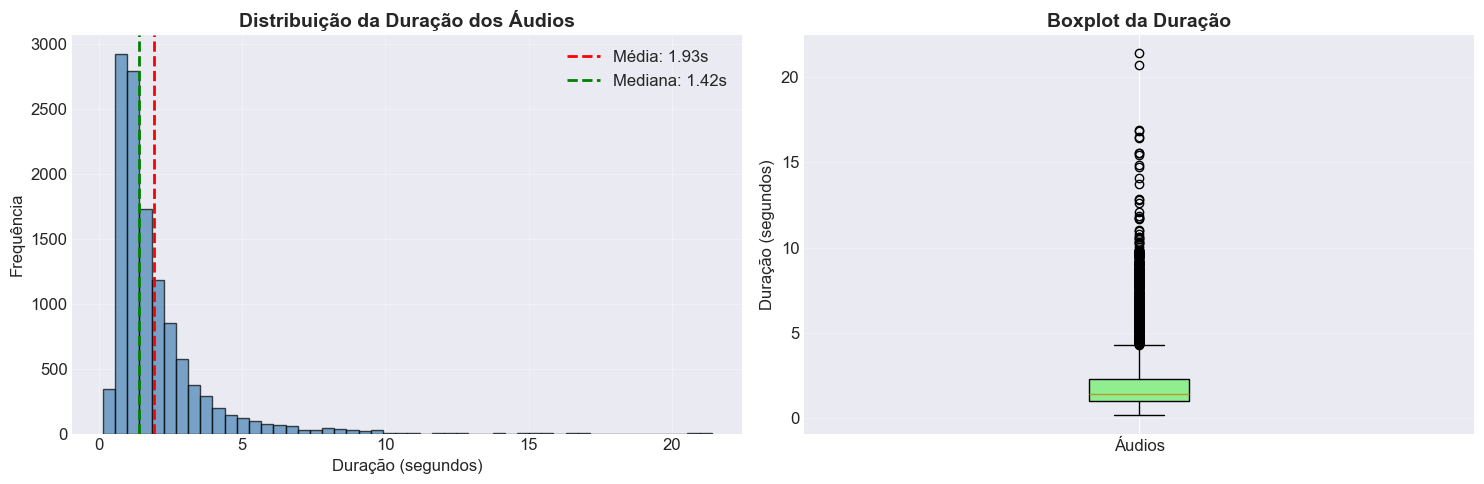


3. ANÁLISE DE FONEMAS (PARA MÉTRICA CER)

📝 Estatísticas gerais:
  • Total de caracteres (com espaços): 144132
  • Total de caracteres (sem espaços): 119185
  • Caracteres únicos (com espaços): 50
  • Caracteres únicos (sem espaços): 49

📊 Tamanho das transcrições (caracteres sem espaços):
  • Média:    9.9
  • Mediana:  6.0
  • Mínimo:   1
  • Máximo:   121
  • Desvio padrão: 9.6

3.3 ANÁLISE DE FONEMAS RAROS (CAUDA LONGA)
----------------------------------------
🔴 Muito raros (< 50): 8 fonemas
🟡 Raros (50-500): 2 fonemas
🟢 Comuns (>500): 39 fonemas

Exemplos de fonemas muito raros:
  'ɟ': 5 ocorrências
  'x': 9 ocorrências
  'ʁ': 11 ocorrências
  'ʝ': 13 ocorrências
  'c': 14 ocorrências
  'ç': 19 ocorrências
  'ʒ': 27 ocorrências
  'ɬ': 27 ocorrências


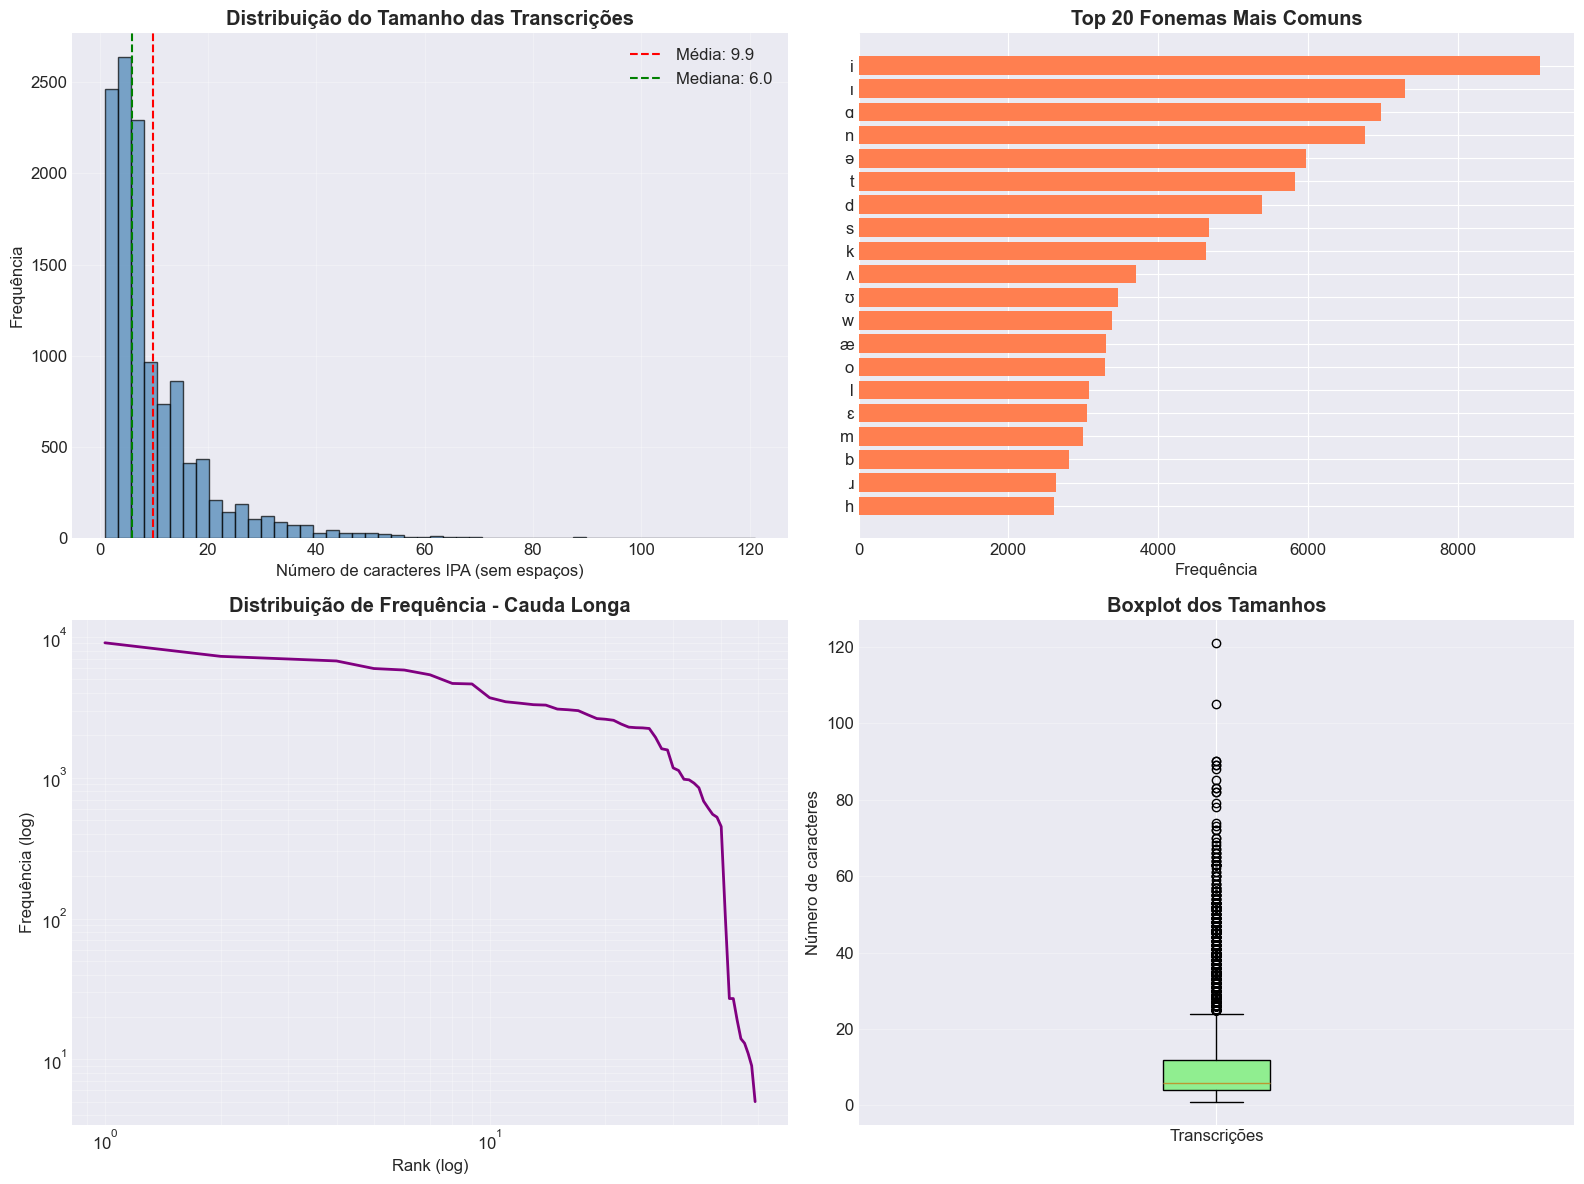


4. ANÁLISE POR FAIXA ETÁRIA

📊 Idade: 3-4
  • Amostras: 10112
  • Tamanho médio: 11.2 caracteres (±11.7)
  • Duração média: 1.67s

📊 Idade: 5-7
  • Amostras: 1893
  • Tamanho médio: 15.3 caracteres (±14.9)
  • Duração média: 3.18s

📊 Idade: 8-11
  • Amostras: 38
  • Tamanho médio: 60.8 caracteres (±11.6)
  • Duração média: 7.37s


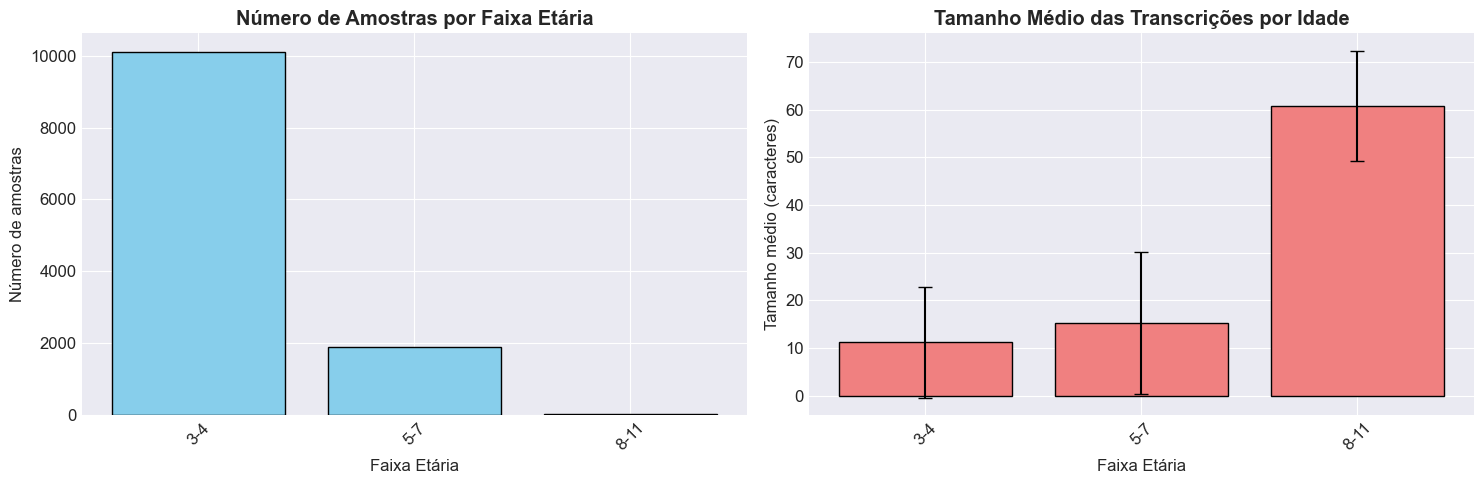


5. ANÁLISE DETALHADA DE UM EXEMPLO

🔊 Exemplo: U_8fecb5f77753c2d6
👤 Idade: 3-4
📝 Transcrição: pʌzəl pis

📊 Informações do áudio:
  • Taxa de amostragem: 48000 Hz
  • Duração: 1.14s
  • Samples: 54912


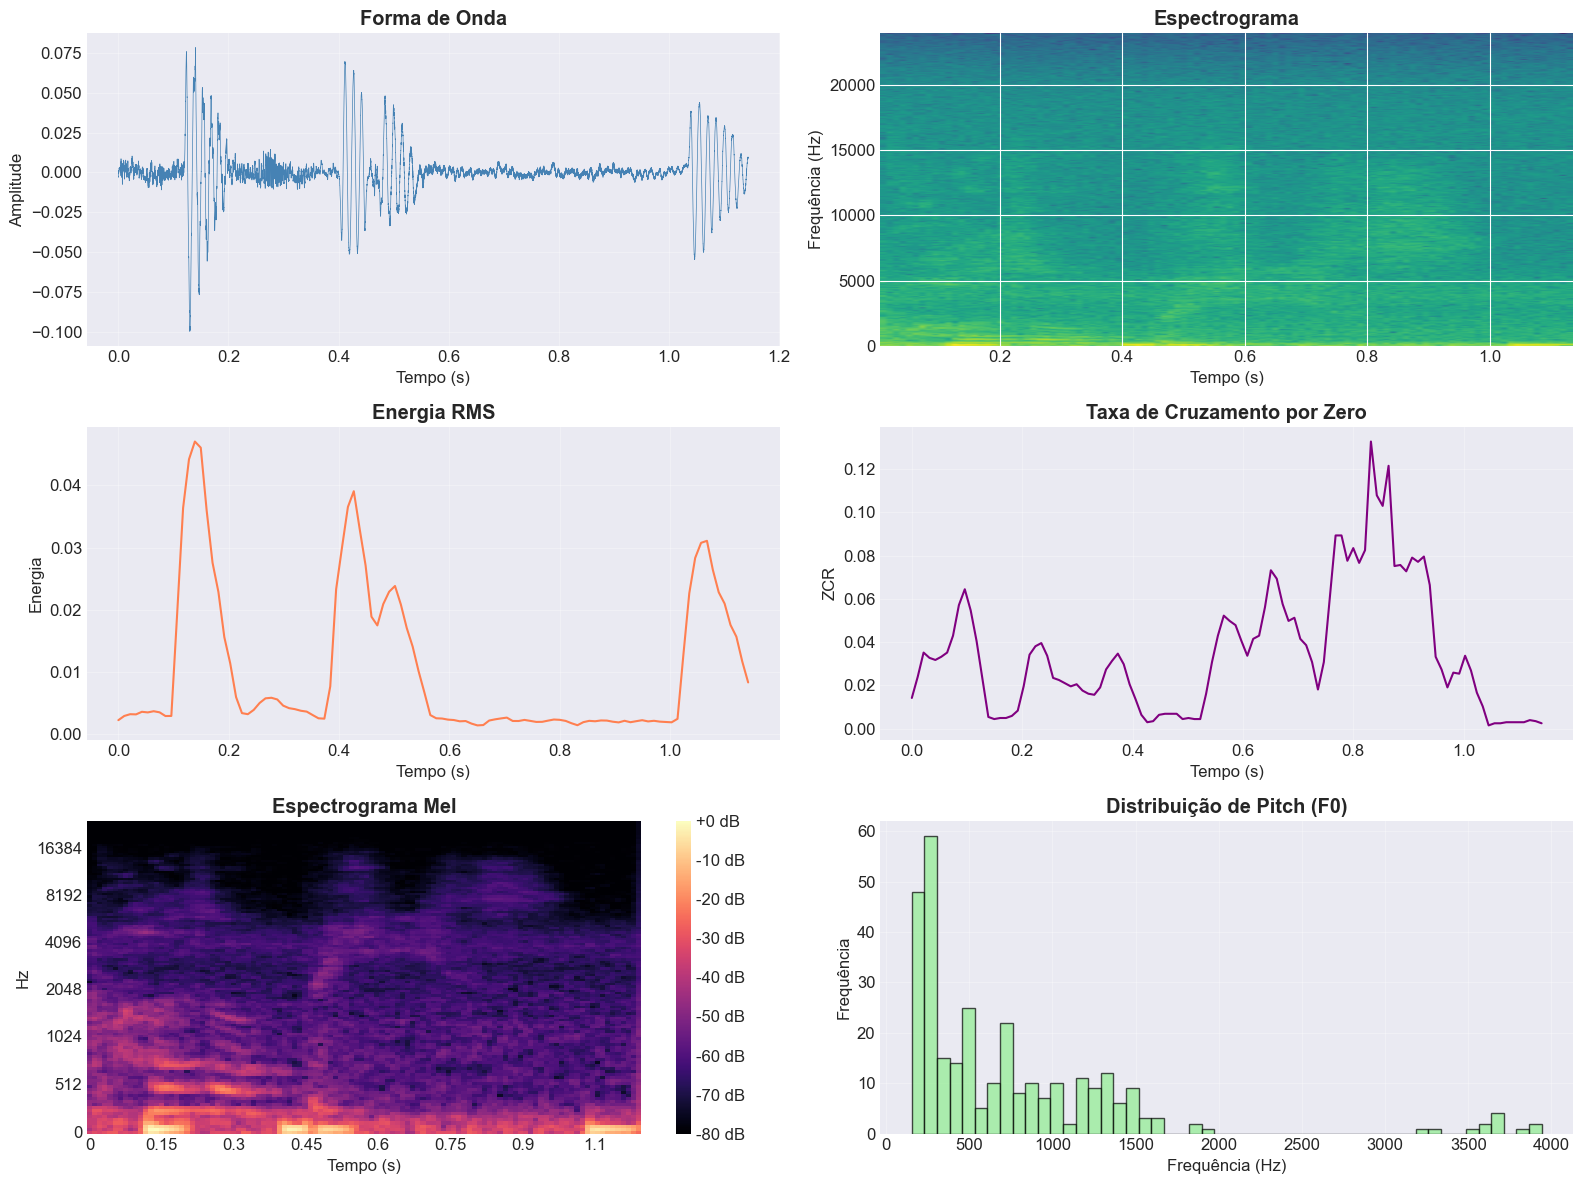


6. RESUMO E RECOMENDAÇÕES PARA O MODELO

📋 RECOMENDAÇÕES PARA SUA SOLUÇÃO:
  1. ⚠️ Precisa aplicar resample para 16kHz no pré-processamento
  2. ✅ 95% dos áudios têm < 5.0s - batch sizes confortáveis
  3. 📊 Dados balanceados por faixa etária - fine-tuning pode ser uniforme

✅ EDA ESPECÍFICA CONCLUÍDA!
📁 Relatórios salvos em: reports/


In [1]:
"""
EDA ESPECÍFICA para On Top of Pasketti - Phonetic Track
Foco: preparação para modelo ASR fonético (WavLM, XLS-R)
"""

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import soundfile as sf
from pathlib import Path
from tqdm import tqdm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configurações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12

# ============================================
# CAMINHOS (conforme sua estrutura)
# ============================================
DATA_DIR = Path("../data/")
AUDIO_DIR = DATA_DIR / "raw"
TRANSCRIPT_FILE = DATA_DIR / "train_phon_transcripts.jsonl"
REPORTS_DIR = Path("reports")
REPORTS_DIR.mkdir(exist_ok=True)

print("="*70)
print("🎯 EDA ESPECÍFICA - PHONETIC TRACK")
print("="*70)
print(f"Data directory: {DATA_DIR.absolute()}")
print(f"Audio directory: {AUDIO_DIR.absolute()}")
print(f"Transcript file: {TRANSCRIPT_FILE.absolute()}")
print("="*70)

# ============================================
# 1. CARREGAR DADOS
# ============================================
print("\n1. CARREGANDO DADOS")
print("-"*50)

# Áudios
audio_files = list(AUDIO_DIR.glob("*.flac"))
print(f"✅ Arquivos .flac: {len(audio_files)}")

# Transcrições
transcricoes = []
with open(TRANSCRIPT_FILE, 'r') as f:
    for line in f:
        transcricoes.append(json.loads(line))

df = pd.DataFrame(transcricoes)
print(f"✅ Transcrições: {len(df)}")
print(f"✅ Correspondência áudio-transcrição: {len(df) == len(audio_files)}")

# ============================================
# 2. ANÁLISE DE ÁUDIO - CRÍTICA PARA ASR
# ============================================
print("\n" + "="*70)
print("2. ANÁLISE DE ÁUDIO (CRÍTICA PARA ASR)")
print("="*70)

# 2.1 Taxa de amostragem (fundamental!)
print("\n2.1 TAXA DE AMOSTRAGEM")
print("-"*30)

sample_rates = []
audio_durations = []
n_amostras = min(500, len(audio_files))  # Analisar 500 áudios

print(f"Analisando {n_amostras} áudios...")
for audio_file in tqdm(audio_files[:n_amostras]):
    info = sf.info(audio_file)
    sample_rates.append(info.samplerate)
    audio_durations.append(info.duration)

# Resultados taxa de amostragem
unique_rates = set(sample_rates)
print(f"\n📊 Taxas de amostragem encontradas: {unique_rates}")

if len(unique_rates) == 1:
    sr = list(unique_rates)[0]
    print(f"✅ Consistente: {sr} Hz")
    print(f"   Modelos como WavLM/XLS-R esperam 16kHz → {'✅ OK' if sr == 16000 else '⚠️ Precisa resample'}")
else:
    print(f"❌ Múltiplas taxas! Precisa unificar para 16kHz")

# 2.2 Duração dos áudios
print("\n2.2 DURAÇÃO DOS ÁUDIOS")
print("-"*30)

duracoes = df['audio_duration_sec'].values if 'audio_duration_sec' in df.columns else audio_durations

print(f"""
📊 Estatísticas de duração (segundos):
  • Média:    {np.mean(duracoes):.2f}s
  • Mediana:  {np.median(duracoes):.2f}s
  • Mínimo:   {np.min(duracoes):.2f}s
  • Máximo:   {np.max(duracoes):.2f}s
  • Desvio padrão: {np.std(duracoes):.2f}s
  
  • Percentil 90: {np.percentile(duracoes, 90):.2f}s
  • Percentil 95: {np.percentile(duracoes, 95):.2f}s
  • Percentil 99: {np.percentile(duracoes, 99):.2f}s
""")

# 2.3 Visualização da duração
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma
axes[0].hist(duracoes, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(np.mean(duracoes), color='red', linestyle='--', linewidth=2, label=f'Média: {np.mean(duracoes):.2f}s')
axes[0].axvline(np.median(duracoes), color='green', linestyle='--', linewidth=2, label=f'Mediana: {np.median(duracoes):.2f}s')
axes[0].set_title('Distribuição da Duração dos Áudios', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Duração (segundos)')
axes[0].set_ylabel('Frequência')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(duracoes, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
axes[1].set_title('Boxplot da Duração', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Duração (segundos)')
axes[1].set_xticklabels(['Áudios'])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'duracao_audios.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 3. ANÁLISE DE FONEMAS - PARA MÉTRICA CER
# ============================================
print("\n" + "="*70)
print("3. ANÁLISE DE FONEMAS (PARA MÉTRICA CER)")
print("="*70)

if 'phonetic_text' in df.columns:
    transcricoes_validas = df['phonetic_text'].dropna()
    
    # 3.1 Análise de caracteres
    todos_caracteres = []
    todos_caracteres_sem_espaco = []
    tamanhos = []
    
    for transc in transcricoes_validas:
        if isinstance(transc, str):
            chars = list(transc)
            todos_caracteres.extend(chars)
            todos_caracteres_sem_espaco.extend([c for c in chars if c != ' '])
            tamanhos.append(len([c for c in chars if c != ' ']))
    
    contagem = Counter(todos_caracteres)
    contagem_sem_espaco = Counter(todos_caracteres_sem_espaco)
    total_chars = len(todos_caracteres)
    
    print(f"\n📝 Estatísticas gerais:")
    print(f"  • Total de caracteres (com espaços): {total_chars}")
    print(f"  • Total de caracteres (sem espaços): {len(todos_caracteres_sem_espaco)}")
    print(f"  • Caracteres únicos (com espaços): {len(contagem)}")
    print(f"  • Caracteres únicos (sem espaços): {len(contagem_sem_espaco)}")
    
    # 3.2 Distribuição de tamanho das transcrições
    print(f"\n📊 Tamanho das transcrições (caracteres sem espaços):")
    print(f"  • Média:    {np.mean(tamanhos):.1f}")
    print(f"  • Mediana:  {np.median(tamanhos):.1f}")
    print(f"  • Mínimo:   {min(tamanhos)}")
    print(f"  • Máximo:   {max(tamanhos)}")
    print(f"  • Desvio padrão: {np.std(tamanhos):.1f}")
    
    # 3.3 Análise de fonemas raros (cauda longa) - CRÍTICO
    print("\n3.3 ANÁLISE DE FONEMAS RAROS (CAUDA LONGA)")
    print("-"*40)
    
    # Classificar fonemas por frequência
    threshold_baixo = 50
    threshold_medio = 500
    
    muito_raros = {c: f for c, f in contagem_sem_espaco.items() if f < threshold_baixo}
    raros = {c: f for c, f in contagem_sem_espaco.items() if threshold_baixo <= f < threshold_medio}
    comuns = {c: f for c, f in contagem_sem_espaco.items() if f >= threshold_medio}
    
    print(f"🔴 Muito raros (< {threshold_baixo}): {len(muito_raros)} fonemas")
    print(f"🟡 Raros ({threshold_baixo}-{threshold_medio}): {len(raros)} fonemas")
    print(f"🟢 Comuns (>{threshold_medio}): {len(comuns)} fonemas")
    
    if len(muito_raros) > 0:
        print(f"\nExemplos de fonemas muito raros:")
        for c, f in sorted(muito_raros.items(), key=lambda x: x[1])[:15]:
            print(f"  '{c}': {f} ocorrências")
    
    # 3.4 Visualização da cauda longa
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Distribuição de tamanhos
    axes[0, 0].hist(tamanhos, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, 0].axvline(np.mean(tamanhos), color='red', linestyle='--', label=f'Média: {np.mean(tamanhos):.1f}')
    axes[0, 0].axvline(np.median(tamanhos), color='green', linestyle='--', label=f'Mediana: {np.median(tamanhos):.1f}')
    axes[0, 0].set_title('Distribuição do Tamanho das Transcrições', fontweight='bold')
    axes[0, 0].set_xlabel('Número de caracteres IPA (sem espaços)')
    axes[0, 0].set_ylabel('Frequência')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Top 20 fonemas
    top20 = sorted(contagem_sem_espaco.items(), key=lambda x: x[1], reverse=True)[:20]
    chars, freqs = zip(*top20)
    y_pos = range(len(chars))
    axes[0, 1].barh(y_pos, freqs, color='coral')
    axes[0, 1].set_yticks(y_pos)
    axes[0, 1].set_yticklabels(chars)
    axes[0, 1].set_title('Top 20 Fonemas Mais Comuns', fontweight='bold')
    axes[0, 1].set_xlabel('Frequência')
    axes[0, 1].invert_yaxis()
    
    # Distribuição de frequência (cauda longa)
    sorted_freqs = sorted(contagem_sem_espaco.values(), reverse=True)
    axes[1, 0].loglog(range(1, len(sorted_freqs)+1), sorted_freqs, linewidth=2, color='purple')
    axes[1, 0].set_title('Distribuição de Frequência - Cauda Longa', fontweight='bold')
    axes[1, 0].set_xlabel('Rank (log)')
    axes[1, 0].set_ylabel('Frequência (log)')
    axes[1, 0].grid(True, alpha=0.3, which='both')
    
    # Boxplot
    axes[1, 1].boxplot(tamanhos, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
    axes[1, 1].set_title('Boxplot dos Tamanhos', fontweight='bold')
    axes[1, 1].set_ylabel('Número de caracteres')
    axes[1, 1].set_xticklabels(['Transcrições'])
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'analise_fonemas_detalhada.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================
# 4. ANÁLISE POR FAIXA ETÁRIA
# ============================================
print("\n" + "="*70)
print("4. ANÁLISE POR FAIXA ETÁRIA")
print("="*70)

if 'age_bucket' in df.columns:
    age_stats = []
    for idade in sorted(df['age_bucket'].unique()):
        subset = df[df['age_bucket'] == idade]
        transc_idade = subset['phonetic_text'].dropna()
        
        if len(transc_idade) > 0:
            tamanhos_idade = [len(str(t)) for t in transc_idade]
            
            stats = {
                'idade': idade,
                'amostras': len(subset),
                'tamanho_medio': np.mean(tamanhos_idade),
                'tamanho_std': np.std(tamanhos_idade),
                'duracao_media': subset['audio_duration_sec'].mean() if 'audio_duration_sec' in subset.columns else 0
            }
            age_stats.append(stats)
            
            print(f"\n📊 Idade: {idade}")
            print(f"  • Amostras: {stats['amostras']}")
            print(f"  • Tamanho médio: {stats['tamanho_medio']:.1f} caracteres (±{stats['tamanho_std']:.1f})")
            print(f"  • Duração média: {stats['duracao_media']:.2f}s")
    
    # Visualização por idade
    df_age = pd.DataFrame(age_stats)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Amostras por idade
    axes[0].bar(df_age['idade'], df_age['amostras'], color='skyblue', edgecolor='black')
    axes[0].set_title('Número de Amostras por Faixa Etária', fontweight='bold')
    axes[0].set_xlabel('Faixa Etária')
    axes[0].set_ylabel('Número de amostras')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Tamanho médio por idade
    axes[1].bar(df_age['idade'], df_age['tamanho_medio'], yerr=df_age['tamanho_std'], 
                color='lightcoral', edgecolor='black', capsize=5)
    axes[1].set_title('Tamanho Médio das Transcrições por Idade', fontweight='bold')
    axes[1].set_xlabel('Faixa Etária')
    axes[1].set_ylabel('Tamanho médio (caracteres)')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'analise_por_idade.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================
# 5. ANÁLISE DE EXEMPLO DETALHADO
# ============================================
print("\n" + "="*70)
print("5. ANÁLISE DETALHADA DE UM EXEMPLO")
print("="*70)

# Escolher um exemplo aleatório
exemplo = df.sample(1).iloc[0]
audio_id = exemplo['utterance_id']
audio_path = AUDIO_DIR / f"{audio_id}.flac"

if audio_path.exists():
    print(f"\n🔊 Exemplo: {audio_id}")
    print(f"👤 Idade: {exemplo.get('age_bucket', 'N/A')}")
    print(f"📝 Transcrição: {exemplo['phonetic_text']}")
    
    # Carregar áudio
    y, sr = librosa.load(audio_path, sr=None)
    
    print(f"\n📊 Informações do áudio:")
    print(f"  • Taxa de amostragem: {sr} Hz")
    print(f"  • Duração: {len(y)/sr:.2f}s")
    print(f"  • Samples: {len(y)}")
    
    # Visualização detalhada
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    
    # Forma de onda
    axes[0, 0].plot(np.linspace(0, len(y)/sr, len(y)), y, color='steelblue', linewidth=0.5)
    axes[0, 0].set_title('Forma de Onda', fontweight='bold')
    axes[0, 0].set_xlabel('Tempo (s)')
    axes[0, 0].set_ylabel('Amplitude')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Espectrograma
    axes[0, 1].specgram(y, Fs=sr, NFFT=1024, noverlap=512, cmap='viridis')
    axes[0, 1].set_title('Espectrograma', fontweight='bold')
    axes[0, 1].set_xlabel('Tempo (s)')
    axes[0, 1].set_ylabel('Frequência (Hz)')
    
    # Energia RMS
    rms = librosa.feature.rms(y=y)[0]
    times = librosa.frames_to_time(range(len(rms)), sr=sr)
    axes[1, 0].plot(times, rms, color='coral')
    axes[1, 0].set_title('Energia RMS', fontweight='bold')
    axes[1, 0].set_xlabel('Tempo (s)')
    axes[1, 0].set_ylabel('Energia')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Taxa de cruzamento por zero
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    axes[1, 1].plot(times, zcr, color='purple')
    axes[1, 1].set_title('Taxa de Cruzamento por Zero', fontweight='bold')
    axes[1, 1].set_xlabel('Tempo (s)')
    axes[1, 1].set_ylabel('ZCR')
    axes[1, 1].grid(True, alpha=0.3)
    
    # Mel-espectrograma
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[2, 0])
    axes[2, 0].set_title('Espectrograma Mel', fontweight='bold')
    axes[2, 0].set_xlabel('Tempo (s)')
    plt.colorbar(axes[2, 0].collections[0], ax=axes[2, 0], format='%+2.0f dB')
    
    # Pitch (fundamental frequency)
    pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
    pitches_flat = pitches[pitches > 0]
    axes[2, 1].hist(pitches_flat, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[2, 1].set_title('Distribuição de Pitch (F0)', fontweight='bold')
    axes[2, 1].set_xlabel('Frequência (Hz)')
    axes[2, 1].set_ylabel('Frequência')
    axes[2, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f'exemplo_{audio_id}.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================
# 6. RESUMO E RECOMENDAÇÕES
# ============================================
print("\n" + "="*70)
print("6. RESUMO E RECOMENDAÇÕES PARA O MODELO")
print("="*70)

# Determinar recomendações baseadas na análise
recomendacoes = []

# Taxa de amostragem
if len(set(sample_rates)) == 1 and list(set(sample_rates))[0] == 16000:
    recomendacoes.append("✅ Taxa de amostragem já é 16kHz - OK para WavLM/XLS-R")
else:
    recomendacoes.append("⚠️ Precisa aplicar resample para 16kHz no pré-processamento")

# Duração
p95_duracao = np.percentile(duracoes, 95)
if p95_duracao < 10:
    recomendacoes.append(f"✅ 95% dos áudios têm < {p95_duracao:.1f}s - batch sizes confortáveis")
else:
    recomendacoes.append(f"⚠️ Áudios longos (até {p95_duracao:.1f}s) - atenção ao padding")

# Fonemas raros
if len(muito_raros) > 10:
    recomendacoes.append(f"⚠️ {len(muito_raros)} fonemas muito raros - considerar data augmentation específico")
    recomendacoes.append("   • SpecAugment (máscara de tempo/frequência)")
    recomendacoes.append("   • Pitch shift moderado (±2 semitons)")

# Variabilidade por idade
if len(age_stats) > 1:
    recomendacoes.append("📊 Dados balanceados por faixa etária - fine-tuning pode ser uniforme")

print("\n📋 RECOMENDAÇÕES PARA SUA SOLUÇÃO:")
for i, rec in enumerate(recomendacoes, 1):
    print(f"  {i}. {rec}")

print("\n" + "="*70)
print("✅ EDA ESPECÍFICA CONCLUÍDA!")
print(f"📁 Relatórios salvos em: {REPORTS_DIR}/")
print("="*70)